<a href="https://colab.research.google.com/github/rahulpirwani7/24k-0657/blob/main/SolarProduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("pythonafroz/solar-powe-generation-data")

print("Dataset downloaded to:")
print(path)

Using Colab cache for faster access to the 'solar-powe-generation-data' dataset.
Dataset downloaded to:
/kaggle/input/solar-powe-generation-data


In [ ]:
print("Files in the dataset:")
for file in os.listdir(path):
    print(file

In [ ]:
files = os.listdir(path)

print("\nFiles in the dataset:")
for file in files:
    print(file)

csv_file = None
for file in files:
    if file.endswith(".csv"):
        csv_file = file
        break

if csv_file is None:
    print("No CSV file found in the dataset.")
else:
    file_path = os.path.join(path, csv_file)
    df = pd.read_csv(file_path)


Files in the dataset:
Solar Power Plant Data.csv


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
zero_rows = df[df['SystemProduction'] == 0]

zero_rows = zero_rows.sample(frac=0.50, random_state=42)
non_zero_rows = df[df['SystemProduction'] != 0]

df_new = pd.concat([zero_rows, non_zero_rows])

df = df_new.sample(frac=1, random_state=42).reset_index(drop=True)

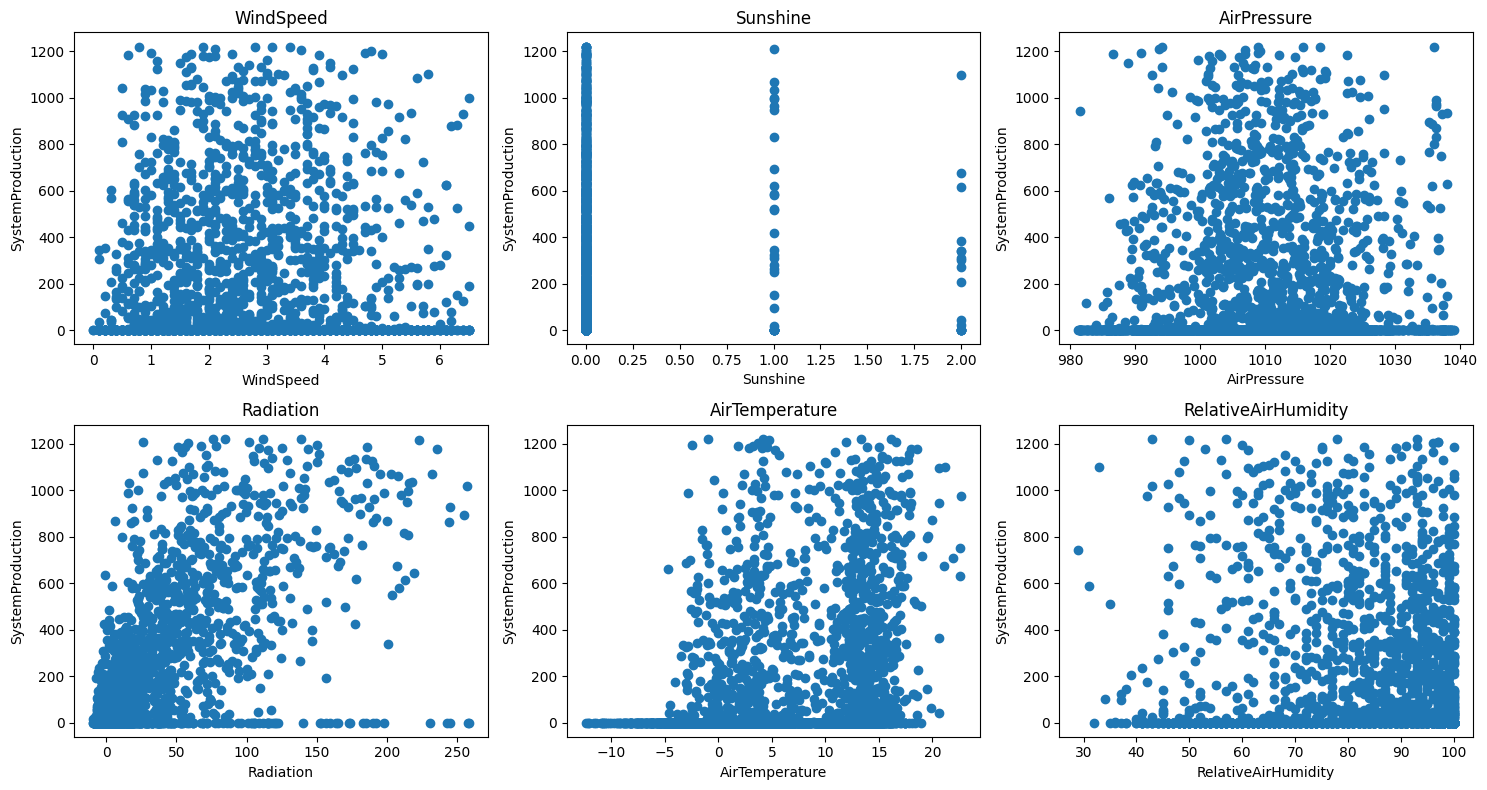

In [ ]:
import matplotlib.pyplot as plt

features = [
    'WindSpeed',
    'Sunshine',
    'AirPressure',
    'Radiation',
    'AirTemperature',
    'RelativeAirHumidity'
]

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

for i, feature in enumerate(features):
    row = i // 3
    col = i % 3

    ax[row, col].scatter(df[feature], df['SystemProduction'])
    ax[row, col].set_title(feature)
    ax[row, col].set_xlabel(feature)
    ax[row, col].set_ylabel("SystemProduction")

plt.tight_layout()
plt.show()

In [ ]:
X=df[['WindSpeed','Sunshine','AirPressure','Radiation','AirTemperature','RelativeAirHumidity']]
y=df['SystemProduction']
df.describe()




,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
count,4854.000000,4854.000000,4854.000000,4854.000000,4854.000000,4854.000000,4854.000000
mean,2.471580,9.063659,1010.069201,67.156139,7.025505,78.906057,372.098560
std,1.455697,19.059016,11.394570,112.455179,7.087289,17.388431,635.184416
min,0.000000,0.000000,981.200000,-9.300000,-12.400000,23.000000,0.000000
25%,1.300000,0.000000,1002.800000,-6.000000,1.000000,67.000000,0.000000
50%,2.200000,0.000000,1010.600000,8.350000,6.700000,83.000000,0.000000
75%,3.400000,1.000000,1017.600000,100.175000,13.375000,94.000000,491.125025
max,7.000000,60.000000,1039.000000,515.200000,24.000000,100.000000,2836.499900


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=5)

X = poly.fit_transform(X)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.linear_model import SGDRegressor

model = SGDRegressor(
    loss='squared_error',
    penalty='l2',
    alpha=(0),
    learning_rate='adaptive',
    eta0=2.85e-5,
    max_iter=50000,
    tol=1e-6,
    random_state=42
)

In [ ]:

X_train,X_temp,y_train,y_temp=train_test_split(X,y,test_size=0.4,random_state=1)
X_Cross,X_test,y_Cross,y_test=train_test_split(X_temp,y_temp,test_size=0.5,random_state=2)



In [ ]:
y=model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
print(mse)
r2=model.score(X_test,y_test)
print(r2)

186453.1735965192
0.5452390131481475


In [ ]:
#  checking for variance and bias of the model
y_pred = model.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print(mse)
r2=model.score(X_train,y_train)
print(r2)


155496.02754415927
0.6065124083324338


In [ ]:
"""
Solar Power Generation - Polynomial + SGDRegressor Pipeline (v2)
=================================================================
Run this in the SAME notebook/session where kagglehub already downloaded
the dataset (so `path` from kagglehub.dataset_download is available), OR
just set CSV_PATH manually if you already know the file location.
"""

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------------------------------------------
# 1. LOCATE + LOAD DATA
# ------------------------------------------------------------------
import kagglehub
path = kagglehub.dataset_download("pythonafroz/solar-powe-generation-data")
print("Downloaded to:", path)

csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
print("CSV files found:", csv_files)

if not csv_files:
    raise FileNotFoundError("No CSV found in downloaded dataset folder — check 'path' contents manually.")

CSV_PATH = csv_files[0]   # change index if the dataset has multiple CSVs
print("Using file:", CSV_PATH)

df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
print(df.head())
print(df.dtypes)
print(df.describe())

# ------------------------------------------------------------------
# 2. BASIC CLEANING
# ------------------------------------------------------------------
obj_cols = df.select_dtypes(include="object").columns.tolist()
high_card_cols = [c for c in obj_cols if df[c].nunique() > 50]
print("Dropping high-cardinality object columns:", high_card_cols)
df = df.drop(columns=high_card_cols, errors="ignore")

datetime_col = None
for c in df.columns:
    if "date" in c.lower() or "time" in c.lower():
        try:
            parsed = pd.to_datetime(df[c], errors="coerce")
            if parsed.notna().mean() > 0.9:
                datetime_col = c
                df[c] = parsed
                break
        except Exception:
            pass

if datetime_col:
    print("Detected datetime column:", datetime_col)
    df["hour"] = df[datetime_col].dt.hour
    df["day_of_year"] = df[datetime_col].dt.dayofyear
    df["month"] = df[datetime_col].dt.month
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
    df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)
    df = df.drop(columns=[datetime_col, "hour", "day_of_year"])

df = df.dropna(axis=1, thresh=int(0.7 * len(df)))
df = df.fillna(df.median(numeric_only=True))

# ------------------------------------------------------------------
# 3. DEFINE TARGET
# ------------------------------------------------------------------
possible_targets = [c for c in df.columns if any(k in c.lower() for k in
                    ["power", "generat", "output", "yield", "energy"])]
TARGET = possible_targets[0] if possible_targets else df.columns[-1]
print("\nAuto-detected target column:", TARGET)
print("(If this is wrong, set TARGET manually to the correct column name.)")

X = df.drop(columns=[TARGET])
y = df[TARGET]
X = X.select_dtypes(include=[np.number])
print("Feature columns used:", list(X.columns))

# ------------------------------------------------------------------
# 4. CORRELATION CHECK
# ------------------------------------------------------------------
corr = pd.concat([X, y], axis=1).corr()[TARGET].sort_values(ascending=False)
print("\nCorrelation with target:\n", corr)

# ------------------------------------------------------------------
# 5. TRAIN / TEST SPLIT
# ------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------------
# 6. PIPELINE: Scale -> Polynomial Features -> SGDRegressor
# ------------------------------------------------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("sgd", SGDRegressor(max_iter=5000, random_state=42, early_stopping=True,
                          n_iter_no_change=10, tol=1e-5))
])

# ------------------------------------------------------------------
# 7. HYPERPARAMETER SEARCH
# ------------------------------------------------------------------
param_grid = {
    "poly__degree": [2, 3, 4, 5],
    "sgd__alpha": [0, 1e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 1e-2],
    "sgd__penalty": ["l2", None],
    "sgd__learning_rate": ["adaptive", "invscaling"],
    "sgd__eta0": [1e-5, 3e-5, 5e-5, 1e-4, 3e-4, 1e-3, 1e-2],
    "sgd__max_iter": [30000, 60000],
    "sgd__tol": [1e-6],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=2,
)

search.fit(X_train, y_train)

print("\nBest params:", search.best_params_)
print("Best CV R2:", search.best_score_)

best_model = search.best_estimator_

# ------------------------------------------------------------------
# 8. EVALUATE ON TEST SET
# ------------------------------------------------------------------
y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- Test Set Performance ---")
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

# ------------------------------------------------------------------
# 9. PLOT PREDICTED VS ACTUAL
# ------------------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Predicted vs Actual (R2={r2:.3f})")
plt.tight_layout()
plt.savefig("pred_vs_actual.png", dpi=150)
plt.show()
print("\nSaved plot to pred_vs_actual.png")

Using Colab cache for faster access to the 'solar-powe-generation-data' dataset.
Downloaded to: /kaggle/input/solar-powe-generation-data
CSV files found: ['/kaggle/input/solar-powe-generation-data/Solar Power Plant Data.csv']
Using file: /kaggle/input/solar-powe-generation-data/Solar Power Plant Data.csv
Shape: (8760, 8)
     Date-Hour(NMT)  WindSpeed  Sunshine  AirPressure  Radiation  \
0  01.01.2017-00:00        0.6         0       1003.8       -7.4   
1  01.01.2017-01:00        1.7         0       1003.5       -7.4   
2  01.01.2017-02:00        0.6         0       1003.4       -6.7   
3  01.01.2017-03:00        2.4         0       1003.3       -7.2   
4  01.01.2017-04:00        4.0         0       1003.1       -6.3   

   AirTemperature  RelativeAirHumidity  SystemProduction  
0             0.1                   97               0.0  
1            -0.2                   98               0.0  
2            -1.2                   99               0.0  
3            -1.3               